In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error, amplitude_damping_error
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import ReadoutError

# 1- Qubit Circuit with Noise Model

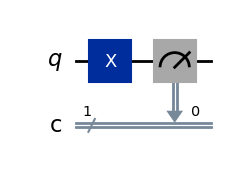

In [2]:
# 1 qubit
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
qc.draw('mpl')


# Create a noise model
noisemodel = NoiseModel()

#### Adding depolarizing error for 1-qubit gates
```python
a = 0.01  
b = 1     
depolarizing_error_1q = depolarizing_error(a, b) 
noisemodel.add_all_qubit_quantum_error(depolarizing_error_1q, ['x', 'h', 'sx', 'id'])
```

here $a$ is the error probability for 1-qubit gates and b is the number of qubits.

Basically we are applying the random Pauli errors with probability a after the execution of all mentioned 1-qubit gate.

then we are adding this error to all qubits for the gates x, h, sx, and id.

#### Adding amplitude damping error for 1-qubit gates
This models the loss of energy (relaxation). Qubits always want to fall to their lowest energy state (∣0⟩).
```python
T1 = 50e3  # T1 time in microseconds
gate_time_1q = 50  # Gate time in microseconds
amplitude_damping_error_1q = amplitude_damping_error(gate_time_1q / T1)
noisemodel.add_all_qubit_quantum_error(amplitude_damping_error_1q, ['x', 'h', 'sx', 'id'])
```
where the probability of amplitude damping error is given by
Here T1 is the relaxation time and t_gate is the gate time.
$$
p_{amp} = 1 - e^{-\frac{t_{gate}}{T_1}}
$$
##### Bloch Sphere Representation of Amplitude Damping Error
<!-- ![Amplitude Damping Error](https://qiskit.org/documentation/_images/amplitude_damping.png) -->
The Bloch Sphere Effect: The entire sphere shrinks toward the North Pole (∣0⟩).
- States on the equator (superpositions) spiral up toward ∣0⟩.
- The South Pole (∣1⟩) moves up toward ∣0⟩.

#### Phase Damping Error
This models loss of quantum information without loss of energy (dephasing). It causes superposition states to lose their phase information.
```python
T2 = 70e3  # T2 time in microseconds
gate_time_1q = 50  # Gate time in microseconds
phase_damping_error_1q = phase_damping_error(gate_time_1q / T2)
noisemodel.add_all_qubit_quantum_error(phase_damping_error_1q, ['x', 'h', 'sx', 'id'])
```
where the probability of phase damping error is given by
Here T2 is the dephasing time and t_gate is the gate time.
$$
p_{phase} = 1 - e^{-\frac{t_{gate}}{T_2}}
$$|


#### Adding thermal relaxation error for 1-qubit gates
This error models both energy relaxation (T1) and dephasing (T2).
```python
T1 = 50e3  # T1 time in microseconds
T2 = 70e3  # T2 time in microseconds
gate_time_1q = 50  # Gate time in microseconds
thermal_relaxation_error_1q = thermal_relaxation_error(gate_time_1q, T1, T2)
noisemodel.add_all_qubit_quantum_error(thermal_relaxation_error_1q, ['x', 'h', 'sx', 'id'])
```

- T1 how fast can a qubit lose energy $|0\rangle\rightarrow|1\rangle$ 
- T2 how fast can a qubit lose phase information $|+\rangle\rightarrow|-\rangle$ 
- **constraint** : $T2 \leq 2*T1$ : we cannot have dephase if we don't have energy relaxation.
where the probability of thermal relaxation error is given by
$$
p_{therm} = 1 - e^{-\frac{t_{gate}}{T_1}}
$$


In [4]:
noisemodel = NoiseModel()
# depolarizing error
error = depolarizing_error(0.1, 1)
noisemodel.add_all_qubit_quantum_error(error, ['x', 'h', 'measure'])
# thermal relaxation error
t1 = 50e3  # T1 time in microseconds
t2 = 70e3  # T2 time in microseconds
gate_time = 100  # gate time in microseconds
thermal_error = thermal_relaxation_error(t1, t2, gate_time)
noisemodel.add_all_qubit_quantum_error(thermal_error, ['x', 'h'])
# amplitude damping error
amp_damp_error = amplitude_damping_error(0.1)
noisemodel.add_all_qubit_quantum_error(amp_damp_error, ['x', 'h'])
# readout error
readout_error = ReadoutError([[0.9, 0.1], [0.2, 0.8]])
noisemodel.add_all_qubit_readout_error(readout_error)


In [5]:
simul = AerSimulator(noise_model=noisemodel)
compiled_circuit = transpile(qc, simul)
result = simul.run(compiled_circuit, shots=1000).result()
counts = result.get_counts()
print(counts)

{'0': 313, '1': 687}


# 2 qubits

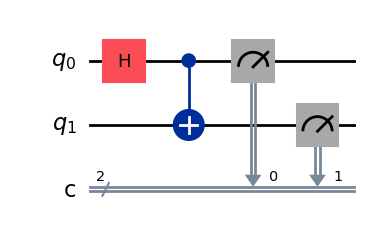

In [7]:
# 2 qubits
qc2 = QuantumCircuit(2, 2)
qc2.h(0)
qc2.cx(0, 1)
qc2.measure([0, 1], [0, 1])
qc2.draw('mpl', fold=-1)

In [11]:
# defining noise
noisemodel2 = NoiseModel()

# time parameters
two_q_gate_time = 200  # in microseconds
gate1_q_gate_time = 50  # in microseconds

# errors

depol_err = depolarizing_error(0.05, 2)
# ther_err = thermal_relaxation_error(50e3, 70e3, ) # for single gatetime
ther_err_q0 = thermal_relaxation_error(t1, t2, gate1_q_gate_time)
ther_err_q1 = thermal_relaxation_error(t1, t2, two_q_gate_time)

ther_err = ther_err_q0.tensor(ther_err_q1)

read_err = ReadoutError([[0.85, 0.15],
                         [0.25, 0.75]])


# on cx gates
noisemodel2.add_all_qubit_quantum_error(depol_err, ['cx'])
noisemodel2.add_all_qubit_quantum_error(ther_err, ['cx'])
# on hadamard gates
noisemodel2.add_all_qubit_quantum_error(ther_err_q0, ['h'])




noisemodel2.add_all_qubit_readout_error(read_err)
simul2 = AerSimulator(noise_model=noisemodel2)
compiled_circuit2 = transpile(qc2, simul2)
result2 = simul2.run(compiled_circuit2, shots=1000).result()

counts2 = result2.get_counts()
print(counts2)


{'01': 152, '10': 164, '00': 377, '11': 307}


As we can see the amount of error has increased due to the addition of noise model.
- 01 : 152
- 10 : 164
- 00 : 377
- 11 : 307

## The End

# fixing bit-flip error

In [ ]:
# creating state \psi = \alpha|000> + \beta|111>

QC = QuantumCircuit(3, 3)
QC.h(0)
QC.cx(0, 1)
